# VAE evaluation

In this notebook, we are going to evalute the training results of the vae (`train_vae.py`). Biggest take away is, are the following:
- Posterior collapse (1–2 of 16 dims active) → low diversity in generated samples
- No class conditioning → mode-averaging instead of class-specific generation
- Narrow generated variance → synthetic data doesn't cover the real data spread

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import torch


from data import CLASSES, BreathDataset, load_dataset, split_dataset
from models.vae import VAE

plt.rcParams.update({'legend.fontsize': 9,
                     'axes.titlesize': 10})

Before starting with the evaluation, we load the best models with there respective checkpoints into a dict and also define some useful variables.

In [2]:
regions = ['mouth', 'nose']
channel_names = ['Humidity in %', 'Temperature in °C']
class_colors = {'bradypnea': 'tab:blue', 'eupnea': 'tab:green', 'tachypnea': 'tab:purple'}
device = torch.device('cuda' if torch.cuda.is_available() else
                      'mps' if torch.backends.mps.is_available() else 'cpu')
models = {} 
datasets = {}
splits = {}

for region in regions:
    # load dataset
    df = load_dataset()
    df = df[df["region"] == region].reset_index(drop=True)
    df_train, df_val, df_test = split_dataset(df, random_state=42)

    # datasets
    train_ds = BreathDataset(df_train)
    val_ds = BreathDataset(df_val,  stats=train_ds.stats)
    test_ds = BreathDataset(df_test, stats=train_ds.stats)
    datasets[region] = {"train": train_ds, "val": val_ds, "test": test_ds}
    splits[region] = {"train": df_train, "val": df_val, "test": df_test}

    # model
    ckpt_path = f"checkpoints/vae_{region}.pt"
    model = VAE(latent_dim=16).to(device)
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    model.eval()

    models[region] = model

We plot total loss, reconstruction loss, and KL divergence over 500 epochs for both mouth and nose VAEs to verify convergence and detect overfitting. The dashed line marks where the $\beta$-warmup reaches $\beta=1$, i.e., where the KL term enters at full weight. Both train and validation losses converge rapidly within ~50 epochs and remain closely aligned throughout, indicating no overfitting. The KL divergence shows a brief spike around the $\beta=1$ transition before settling, suggesting the latent space adjusts smoothly to the full regularization pressure.

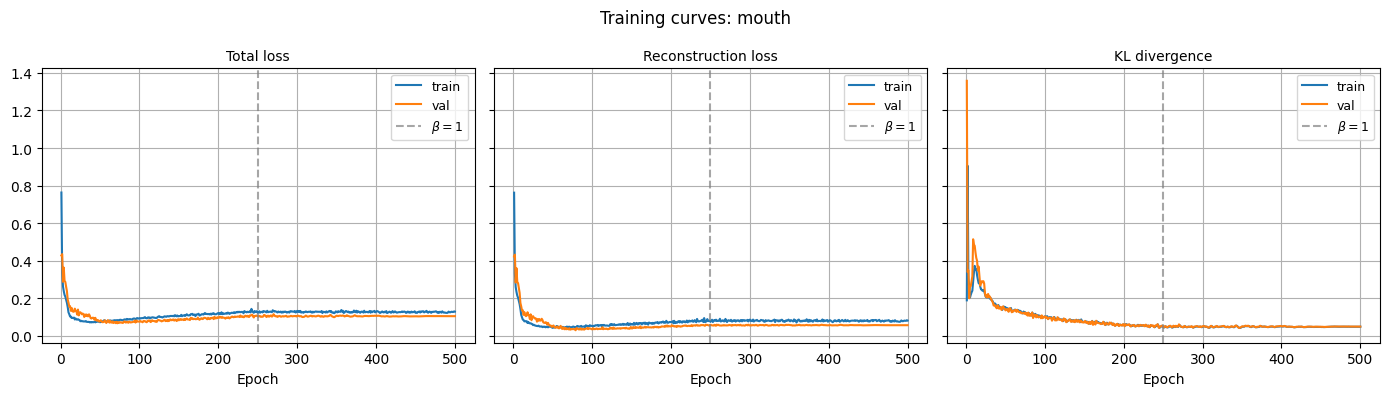

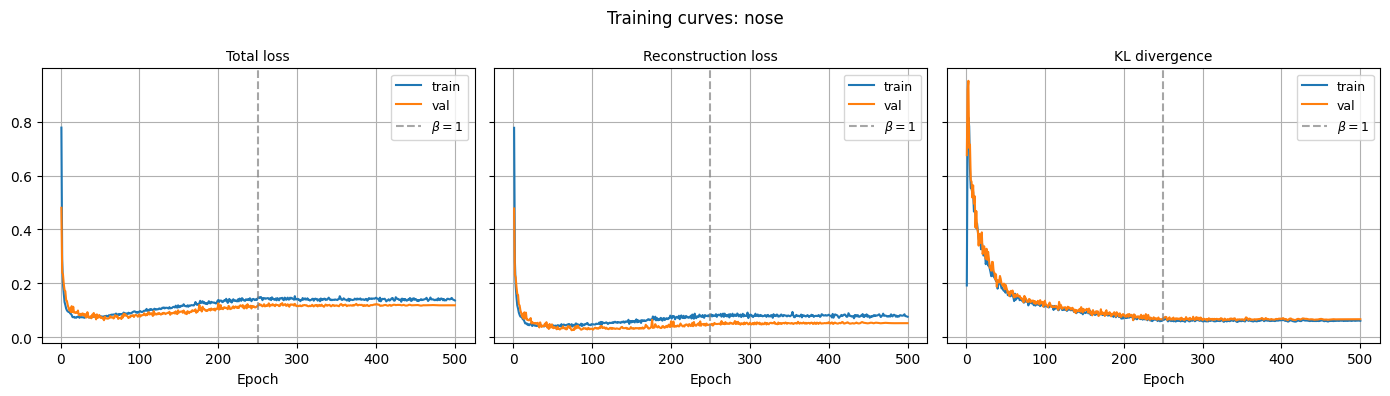

In [3]:
for region in regions:
    path = f'results/vae/train_{region}.csv'
    hist = pd.read_csv(path)
    beta1_epoch = hist.loc[hist['beta'] >= 1.0, 'epoch'].min()

    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
    fig.suptitle(f'Training curves: {region}')
    pairs = [('train_loss', 'val_loss', 'Total loss'),
            ('train_recon', 'val_recon','Reconstruction loss'),
            ('train_kl', 'val_kl', 'KL divergence')]
    for ax, (tr_col, vl_col, title) in zip(axes, pairs):
        ax.plot(hist['epoch'], hist[tr_col], label='train')
        ax.plot(hist['epoch'], hist[vl_col], label='val')
        ax.axvline(beta1_epoch, color='gray', linestyle='--', alpha=0.7, label=r'$\beta=1$')
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid()
    plt.tight_layout()
    plt.show()

We overlay real and reconstructed signals for randomly selected validation samples to qualitatively assess whether the VAE captures the key temporal dynamics, onset timing, rise slope, and saturation level, across both channels (humidity, temperature) and both modalities (mouth, nose).

**Mouth**: Reconstructions closely track the overall signal shape, correctly reproducing the sharp humidity rise onset and the saturation plateau around 50–60%. The model slightly smooths over rapid transients (e.g., Sample 140's steep rise edge), which is expected VAE behavior due to the probabilistic bottleneck. Temperature reconstructions follow the general trend but show minor amplitude overestimation.

**Nose**: Reconstructions are qualitatively good but visibly smoother, with the model occasionally lagging the onset timing (e.g., Sample 195) or over-smoothing plateau fluctuations. This is consistent with the noisier nose signals and the slightly higher reconstruction loss observed in the training curves. Temperature channel fidelity is comparable to mouth.

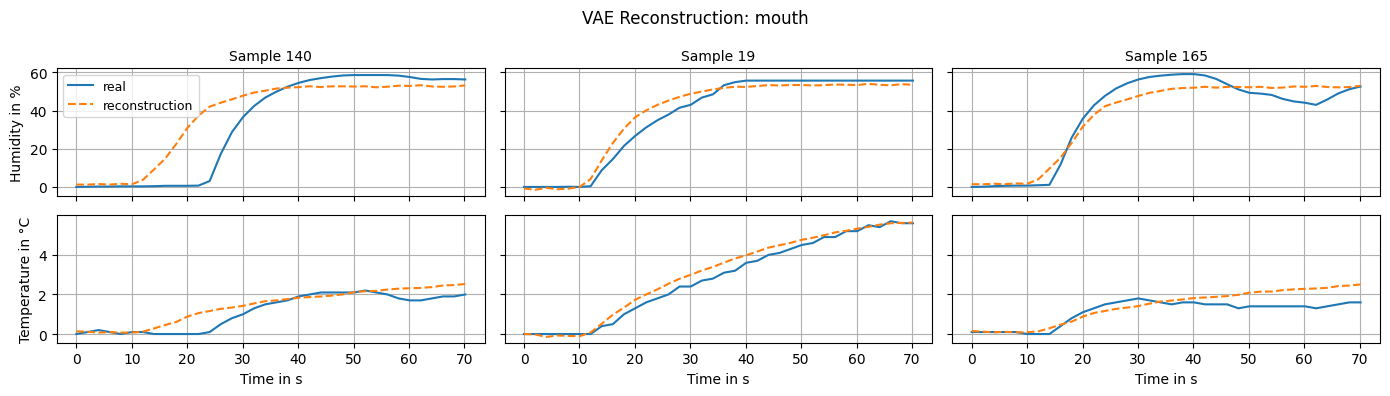

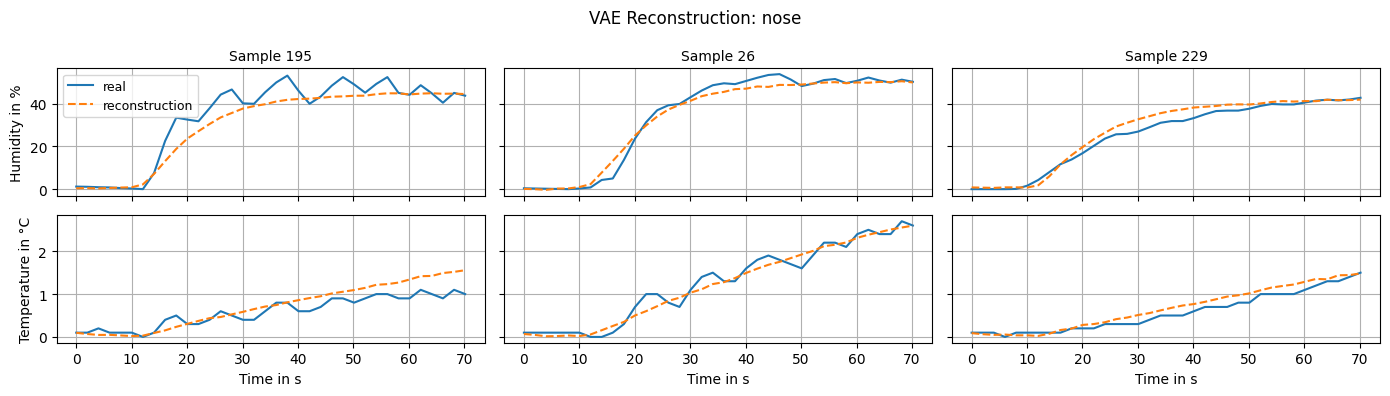

In [4]:
for region in regions:
    train_ds = datasets[region]['train']
    model = models[region]
    model.eval()

    # denormalization
    mean = train_ds.stats['mean'][:, None]
    std  = train_ds.stats['std'][:, None]
    def denorm(x):
        return x * std + mean

    fig, axes = plt.subplots(2, 3, figsize=(14, 4), sharex=True, sharey='row')
    fig.suptitle(f'VAE Reconstruction: {region}')

    # sample 3 signals from train_ds
    sample_indices = np.random.default_rng(42).choice(len(train_ds), size=3, replace=False)
    for col, idx in enumerate(sample_indices):
        signal, time, label = train_ds[idx]
        signal_batch = signal.unsqueeze(0).to(device)
        with torch.no_grad():
            x_hat, _, _ = model(signal_batch)
        x_hat      = denorm(x_hat.squeeze(0).cpu().numpy())
        signal_np  = denorm(signal.numpy())
        time_np    = time.numpy()

        for row in range(2):
            ax = axes[row, col]
            ax.plot(time_np, signal_np[row], label='real', color='tab:blue')
            ax.plot(time_np, x_hat[row], label='reconstruction', color='tab:orange', linestyle='--')
            ax.grid()
            axes[row, 0].set_ylabel(channel_names[row])
            axes[0, col].set_title(f'Sample {idx}')
            axes[0, 0].legend(loc='upper left')
            axes[-1, col].set_xlabel('Time in s')
    plt.tight_layout()
    plt.show()

We compare per-class reconstruction error on the test set to check whether the VAE encodes all breathing patterns equally well or exhibits bias toward certain classes, which would affect synthetic data quality downstream. Eupnea achieves the lowest MSE (~0.038), followed by bradypnea (~0.050) and tachypnea (~0.060). This ordering is plausible, eupnea signals are the most regular and thus easiest to reconstruct, while tachypnea's faster dynamics and bradypnea's larger variance make them slightly harder to capture. Reconstruction quality is reasonably uniform across classes for both modalities, with no single class being drastically under-represented in the latent space. The wide error bars reflect sample-level variability rather than systematic bias.

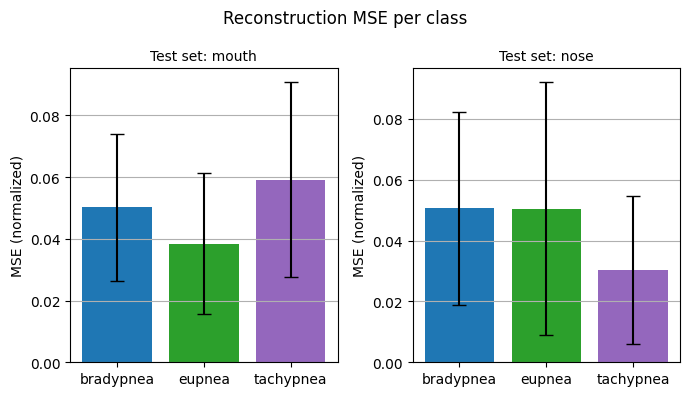

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(7, 4))
plt.suptitle('Reconstruction MSE per class')
for region_idx, region in enumerate(regions):
    test_ds = datasets[region]['test']
    model = models[region]
    model.eval()

    mse_per_class = {i: [] for i in range(len(CLASSES))}
    with torch.no_grad():
        for i in range(len(test_ds)):
            signal, _, label = test_ds[i]
            x_hat, _, _ = model(signal.unsqueeze(0).to(device))
            mse = (x_hat.squeeze(0) - signal.to(device)).pow(2).mean().item()
            mse_per_class[label].append(mse)
    means = [np.mean(mse_per_class[i]) for i in range(len(CLASSES))]
    stds  = [np.std(mse_per_class[i])  for i in range(len(CLASSES))]

    ax = fig.axes[region_idx]
    ax.bar(CLASSES, means, yerr=stds, capsize=5, color=list(class_colors.values()))
    ax.set_ylabel('MSE (normalized)')
    ax.set_title(f'Test set: {region}')
    ax.grid(axis='y')
plt.tight_layout()
plt.show()

We project the learned latent representations onto their first two principal components to visualize whether the VAE organizes breathing classes into separable regions, which is a prerequisite for generating class-coherent synthetic samples.

**Mouth:** PC1 captures 97.1% of the variance, indicating a nearly one-dimensional latent manifold. Classes show partial ordering along PC1, tachypnea tends toward positive values, bradypnea toward negative, but overlap is substantial, especially between eupnea and the other two. The high PC1 dominance suggests the VAE primarily encodes a single axis of variation (likely signal amplitude/onset timing).

**Nose:** Variance is more distributed (PC1: 89.7%, PC2: 10.1%), yielding a richer two-dimensional structure. Classes overlap more heavily overall, consistent with the noisier, lower-contrast nose signals. There is no clean clustering, though tachypnea again shows a slight tendency toward specific regions.

The latent space captures meaningful variation but does not produce fully separable class clusters, which is expected for a standard (non-conditional) VAE trained without label supervision. For conditional generation, this motivates either conditioning the decoder on class labels or sampling from class-specific latent subregions.

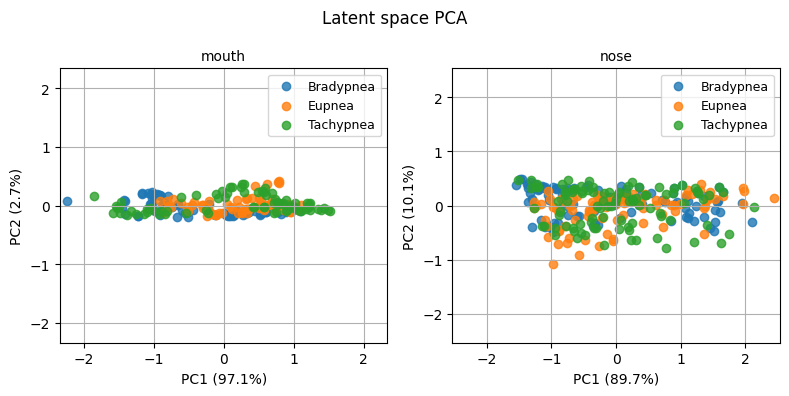

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
plt.suptitle('Latent space PCA')


for col, region in enumerate(regions):
    train_ds = datasets[region]['train']
    model = models[region]
    model.eval()

    model.eval()
    mus, labels = [], []
    with torch.no_grad():
        for i in range(len(train_ds)):
            signal, _, label = train_ds[i]
            mu, _ = model.encoder(signal.unsqueeze(0).to(device))
            mus.append(mu.squeeze(0).cpu().numpy())
            labels.append(label)
    mus    = np.stack(mus)
    labels = np.array(labels)
    pca    = PCA(n_components=2)
    z2d    = pca.fit_transform(mus)

    for i, cls in enumerate(CLASSES):
        mask = labels == i
        ax[col].scatter(z2d[mask, 0], z2d[mask, 1], label=cls.capitalize(), alpha=0.8)
    lim_max = max(np.abs(z2d[:, 0]).max(), np.abs(z2d[:, 1]).max())
    ax[col].set_xlim(-lim_max - 0.1, lim_max + 0.1)
    ax[col].set_ylim(-lim_max - 0.1, lim_max + 0.1)
    ax[col].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    ax[col].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    ax[col].set_title(region)
    ax[col].legend(loc='upper right')
    ax[col].grid()

plt.tight_layout()
plt.show()


We inspect the per-dimension KL divergence to diagnose how many latent dimensions the VAE actively uses versus how many collapse to the prior (posterior collapse). Dimensions above the 0.1 threshold are considered "active," i.e., encoding meaningful information beyond the standard normal prior. Both models exhibit significant posterior collapse, using only 1–2 out of 16 latent dimensions. This is not necessarily problematic, it suggests the breath signals have low intrinsic dimensionality, but it means the latent space is largely redundant. If richer representations are needed downstream, reducing the latent dimension or increasing β could be considered.

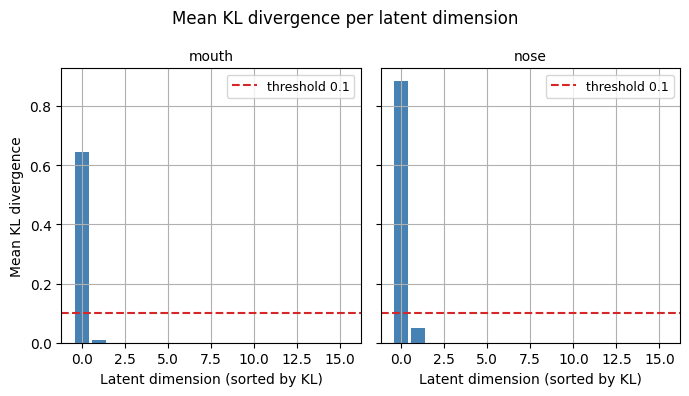

In [7]:
fig, ax = plt.subplots(1, 2,figsize=(7, 4), sharey=True)
plt.suptitle('Mean KL divergence per latent dimension')

for region_idx, region in enumerate(regions):
    train_ds = datasets[region]['train']
    model = models[region]
    model.eval()
    kl_dims = []
    with torch.no_grad():
        for i in range(len(train_ds)):
            signal, _, _ = train_ds[i]
            mu, logvar = model.encoder(signal.unsqueeze(0).to(device))
            kl = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())
            kl_dims.append(kl.squeeze(0).cpu().numpy())
    kl_dims = np.stack(kl_dims).mean(0)
    order   = np.argsort(kl_dims)[::-1]

    ax = fig.axes[region_idx]
    ax.bar(range(len(kl_dims)), kl_dims[order], color='steelblue')
    ax.axhline(0.1, color='tab:red', linestyle='--', label='threshold 0.1')
    ax.set_xlabel('Latent dimension (sorted by KL)')
    ax.set_title(region)
    ax.legend()
    ax.grid()

fig.axes[0].set_ylabel('Mean KL divergence')
plt.tight_layout()
plt.show()


We sample from the learned prior $z \sim \mathcal{N}(0, I)$ and decode to inspect whether the VAE produces physically plausible breath signals, correct temporal structure (baseline → rise → saturation), realistic amplitude ranges, and coherent humidity-temperature coupling. The mouth VAE generates diverse, physically realistic samples. The nose VAE produces plausible but overly homogeneous outputs, a direct consequence of its more collapsed latent space. For downstream augmentation, nose samples may need additional strategies (e.g., latent space interpolation or noise injection) to improve diversity.

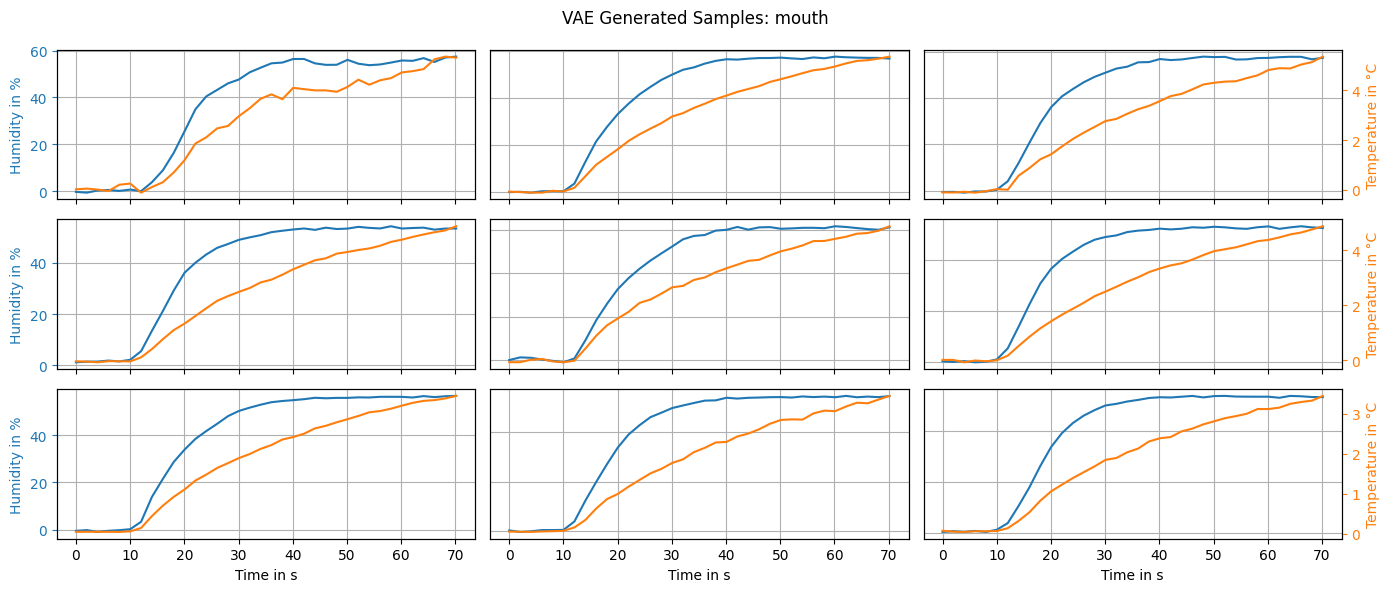

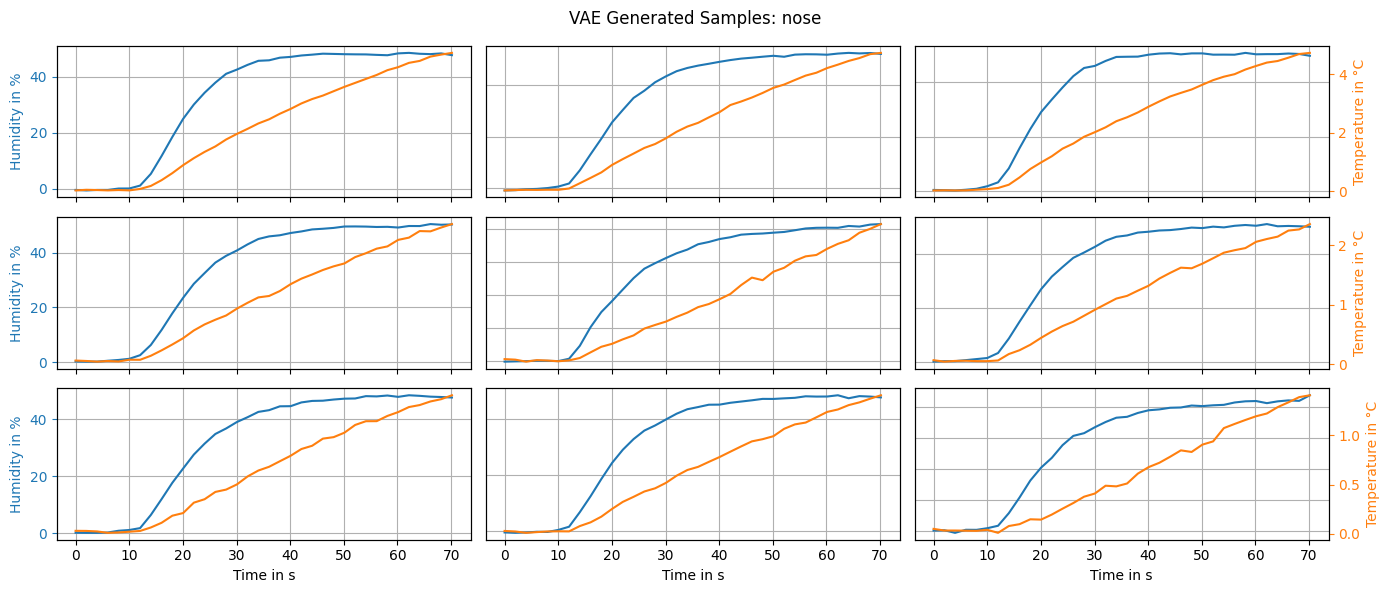

In [8]:
for region in regions:
    train_ds = datasets[region]['train']
    model = models[region]
    model.eval()
    
    # denormalization
    mean = train_ds.stats['mean'][:, None]
    std  = train_ds.stats['std'][:, None]
    def denorm(x):
        return x * std + mean
    
    # plot
    samples  = denorm(model.sample(9, device).cpu().numpy())
    time_np  = train_ds[0][1].numpy()

    fig, axes = plt.subplots(3, 3, figsize=(14, 6), sharex=True, sharey=False)
    fig.suptitle(f'VAE Generated Samples: {region}')
    for i, ax in enumerate(axes.flatten()):
        row = i // 3
        col = i % 3
        l1, = ax.plot(time_np, samples[i, 0], color='tab:blue', label='Humidity in %')
        ax.grid()
        ax_r = ax.twinx()
        l2, = ax_r.plot(time_np, samples[i, 1], color='tab:orange', label='Temperature in °C')
        if col == 0:
            ax.set_ylabel('Humidity in %', color='tab:blue')
            ax.tick_params(axis='y', colors='tab:blue')
        else:
            ax.set_yticklabels([])
            ax.tick_params(axis='y', length=0)
        if col == 2:
            ax_r.set_ylabel('Temperature in °C', color='tab:orange')
            ax_r.tick_params(axis='y', colors='tab:orange')
        else:
            ax_r.set_yticklabels([])
            ax_r.tick_params(axis='y', length=0)
        if row == 2:
            ax.set_xlabel('Time in s')
    plt.tight_layout()
    plt.show()


We overlay the per-class real signal statistics ($\mu \pm \sigma$) with the unconditional generated distribution to assess whether synthetic samples fall within the real data envelope and which class they most closely resemble. The unconditional VAE generates signals that are statistically plausible (within the real data envelope) but mode-averaging, it converges toward the dataset mean rather than preserving class-specific characteristics. This confirms that for class-conditional synthetic data generation, explicit conditioning (e.g., CVAE or class-guided sampling) will be necessary.

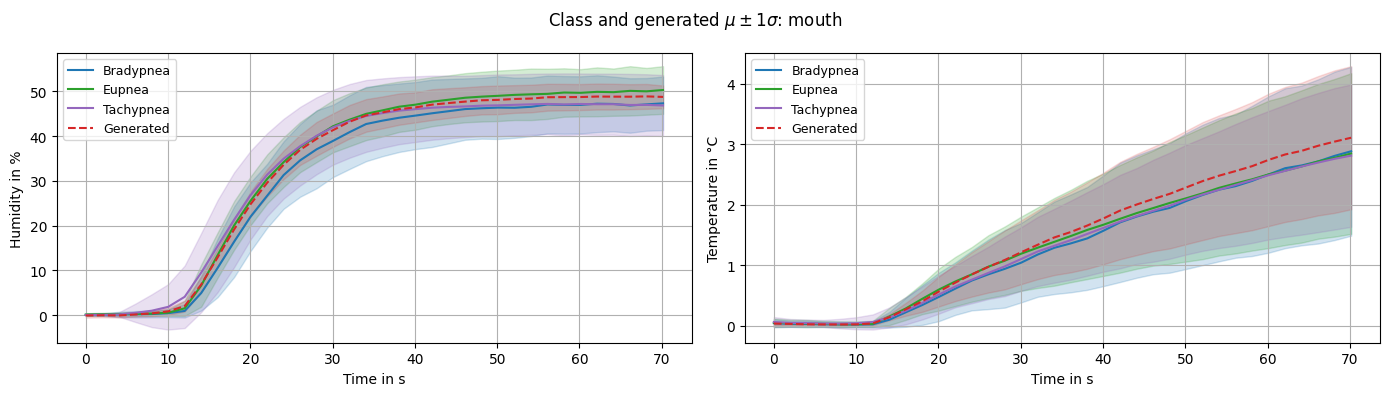

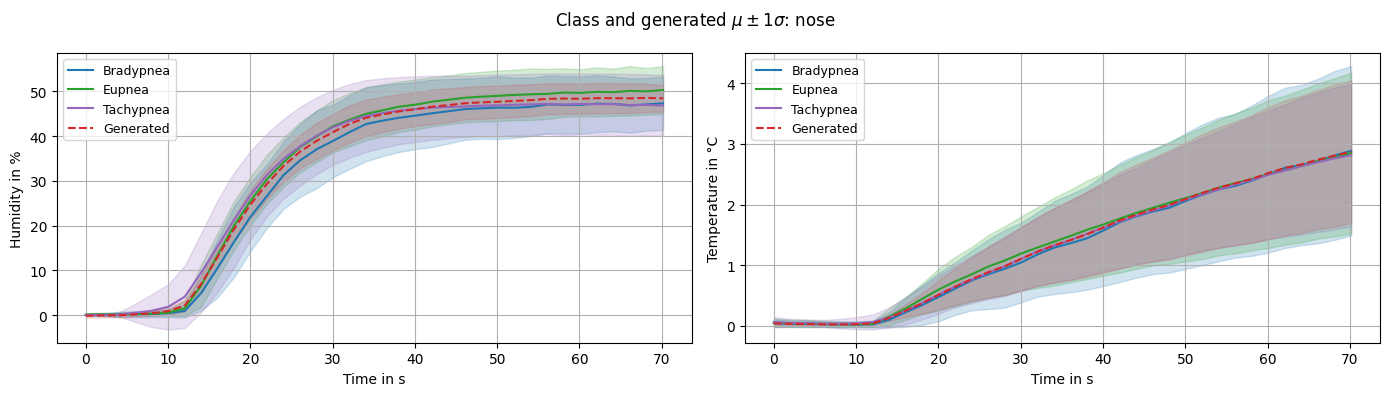

In [9]:
n_gen=200
for region in regions:
    mean_s = train_ds.stats['mean'][:, None]
    std_s  = train_ds.stats['std'][:, None]
    def denorm(x): return x * std_s + mean_s

    real = {i: [] for i in range(len(CLASSES))}
    for i in range(len(train_ds)):
        signal, _, label = train_ds[i]
        real[label].append(denorm(signal.numpy()))
    time_np = train_ds[0][1].numpy()
    gen     = denorm(model.sample(n_gen, device).cpu().numpy())

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(rf'Class and generated $\mu \pm 1\sigma$: {region}')
    for ch, ax in enumerate(axes):
        for cls_idx, (cls_name, color) in enumerate(zip(CLASSES, class_colors.values())):
            sigs = np.stack(real[cls_idx])[:, ch, :]
            m, s = sigs.mean(0), sigs.std(0)
            ax.plot(time_np, m, color=color, label=cls_name.capitalize())
            ax.fill_between(time_np, m - s, m + s, alpha=0.2, color=color)
        m_gen, s_gen = gen[:, ch, :].mean(0), gen[:, ch, :].std(0)
        ax.plot(time_np, m_gen, color='tab:red', linestyle='--', label='Generated')
        ax.fill_between(time_np, m_gen - s_gen, m_gen + s_gen, alpha=0.15, color='tab:red')
        ax.set_ylabel(channel_names[ch])
        ax.set_xlabel('Time in s')
        ax.legend(loc='upper left')
        ax.grid()
    plt.tight_layout()
    plt.show()


We linearly interpolate between the latent encodings of a bradypnea and a tachypnea sample ($\alpha = 0 \to 1$) to verify that the latent space is smooth and semantically meaningful, i.e., intermediate points decode into physically plausible signals with gradually transitioning characteristics rather than producing artifacts or abrupt jumps. The latent space supports smooth, physically meaningful interpolation between classes, confirming that the VAE has learned a continuous manifold rather than disconnected clusters. This property is valuable for generating synthetic samples at arbitrary points along the breathing-rate spectrum, not just at the three discrete class labels.

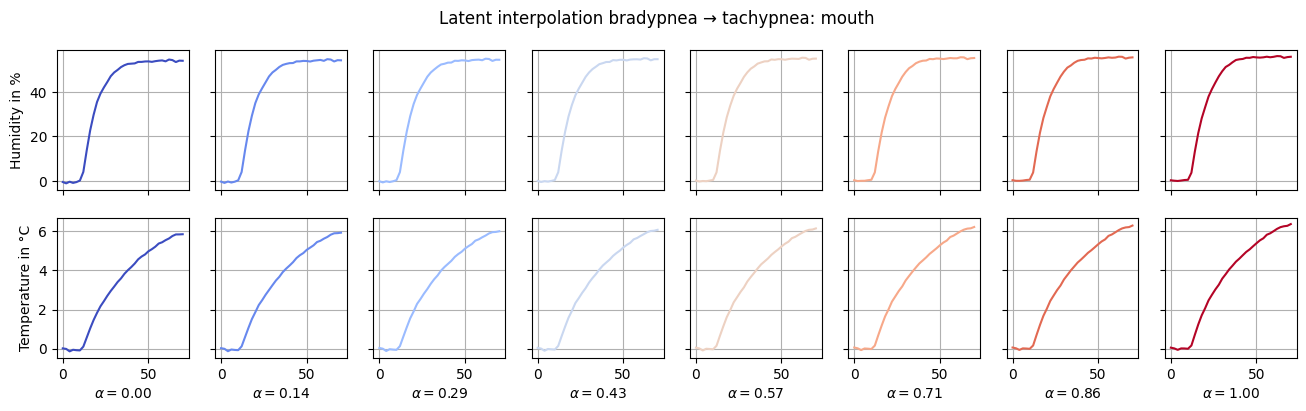

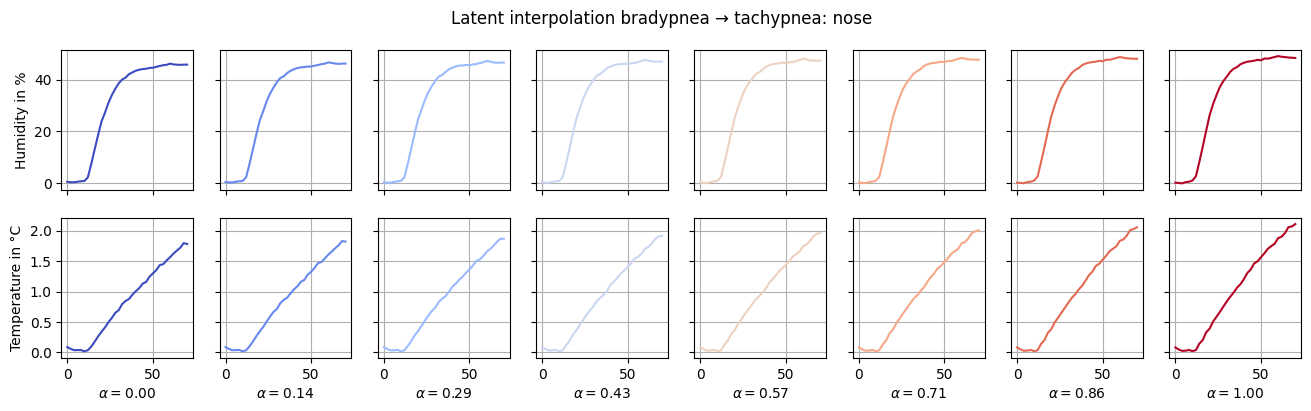

In [10]:
n_steps=8
for region in regions:
    train_ds = datasets[region]['train']
    model = models[region]
    model.eval()
    mean_s = train_ds.stats['mean'][:, None]
    std_s  = train_ds.stats['std'][:, None]
    def denorm(x): return x * std_s + mean_s

    # find one bradypnea (0) and one tachypnea (2) sample
    idx_a = idx_b = None
    for i in range(len(train_ds)):
        _, _, label = train_ds[i]
        if idx_a is None and label == 0:
            idx_a = i
        if idx_b is None and label == 2:
            idx_b = i
        if idx_a is not None and idx_b is not None:
            break

    sig_a = train_ds[idx_a][0].unsqueeze(0).to(device)
    sig_b = train_ds[idx_b][0].unsqueeze(0).to(device)
    with torch.no_grad():
        mu_a, _ = model.encoder(sig_a)
        mu_b, _ = model.encoder(sig_b)

    alphas  = torch.linspace(0, 1, n_steps, device=device)
    time_np = train_ds[0][1].numpy()
    cmap    = plt.cm.coolwarm

    fig, axes = plt.subplots(2, n_steps, figsize=(16, 4), sharex=True, sharey='row')
    fig.suptitle(f'Latent interpolation bradypnea → tachypnea: {region}')
    with torch.no_grad():
        for col, alpha in enumerate(alphas):
            z     = (1 - alpha) * mu_a + alpha * mu_b
            x_hat = denorm(model.decoder(z).squeeze(0).cpu().numpy())
            for row in range(2):
                axes[row, col].plot(time_np, x_hat[row], color=cmap(alpha.item()))
                axes[row, col].grid()
                if col == 0:
                    axes[row, col].set_ylabel(channel_names[row])
                if row == 1:
                    axes[row, col].set_xlabel(rf'$\alpha={alpha:.2f}$')